# Air Quality Index Prediction
This project aims to develop a predictive model for estimating air quality index (AQI) based on various environmental factors.

## Importing Required Libraries
We start by importing essential libraries for data manipulation, visualization, and model training.

In [27]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Deep learning (MLP)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

2026-04-20 13:17:27.082278: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## Loading and Exploring the Dataset
We load the dataset and perform initial exploration to understand its structure and characteristics.

In [29]:
# Load Dataset
file_path = "city_day.csv"  #https://www.kaggle.com/code/anjusunilkumar/air-quality-index-prediction?select=city_day.csv
df = pd.read_csv(file_path)

In [31]:
#Display Dataset
df

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29526,Visakhapatnam,2020-06-27,15.02,50.94,7.68,25.06,19.54,12.47,0.47,8.55,23.30,2.24,12.07,0.73,41.0,Good
29527,Visakhapatnam,2020-06-28,24.38,74.09,3.42,26.06,16.53,11.99,0.52,12.72,30.14,0.74,2.21,0.38,70.0,Satisfactory
29528,Visakhapatnam,2020-06-29,22.91,65.73,3.45,29.53,18.33,10.71,0.48,8.42,30.96,0.01,0.01,0.00,68.0,Satisfactory
29529,Visakhapatnam,2020-06-30,16.64,49.97,4.05,29.26,18.80,10.03,0.52,9.84,28.30,0.00,0.00,0.00,54.0,Satisfactory


In [33]:
# Display basic info about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29531 entries, 0 to 29530
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   City        29531 non-null  object 
 1   Date        29531 non-null  object 
 2   PM2.5       24933 non-null  float64
 3   PM10        18391 non-null  float64
 4   NO          25949 non-null  float64
 5   NO2         25946 non-null  float64
 6   NOx         25346 non-null  float64
 7   NH3         19203 non-null  float64
 8   CO          27472 non-null  float64
 9   SO2         25677 non-null  float64
 10  O3          25509 non-null  float64
 11  Benzene     23908 non-null  float64
 12  Toluene     21490 non-null  float64
 13  Xylene      11422 non-null  float64
 14  AQI         24850 non-null  float64
 15  AQI_Bucket  24850 non-null  object 
dtypes: float64(13), object(3)
memory usage: 3.6+ MB


## Data Preprocessing
This step involves handling missing values, encoding categorical features, and normalizing numerical features.

In [35]:
# Che+ck the total null values
df.isnull().sum()

City              0
Date              0
PM2.5          4598
PM10          11140
NO             3582
NO2            3585
NOx            4185
NH3           10328
CO             2059
SO2            3854
O3             4022
Benzene        5623
Toluene        8041
Xylene        18109
AQI            4681
AQI_Bucket     4681
dtype: int64

In [37]:
# Handling missing values
# Drop rows where AQI is missing, as it's our target variable
df = df.dropna(subset=['AQI'])
print(len(df))
df.isnull().sum()

24850


City              0
Date              0
PM2.5           678
PM10           7086
NO              387
NO2             391
NOx            1857
NH3            6536
CO              445
SO2             605
O3              807
Benzene        3535
Toluene        5826
Xylene        15372
AQI               0
AQI_Bucket        0
dtype: int64

## Exploratory Data Analysis (EDA)
We visualize the data to identify patterns, correlations, and important features.

In [39]:
# Fill missing values only in numeric columns with their respective column means
df.fillna(df.select_dtypes(include=['number']).mean(), inplace=True)

/var/folders/fd/kh5_s1z10153b5vzkftx7gmw0000gn/T/ipykernel_84931/200307737.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.fillna(df.select_dtypes(include=['number']).mean(), inplace=True)


In [41]:
# Drop non-numeric and irrelevant columns
drop_columns = ['City', 'Date', 'AQI_Bucket']  # 'City' and 'Date' are categorical, 'AQI_Bucket' is redundant
df = df.drop(columns=drop_columns)

In [43]:
# Define target (dependent variable) and features (independent variables)
target = 'AQI'
features = [col for col in df.columns if col != target]  # All columns except AQI
print(features)

X = df[features]  # Features dataset
y = df[target]  # Target variable

['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3', 'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene']


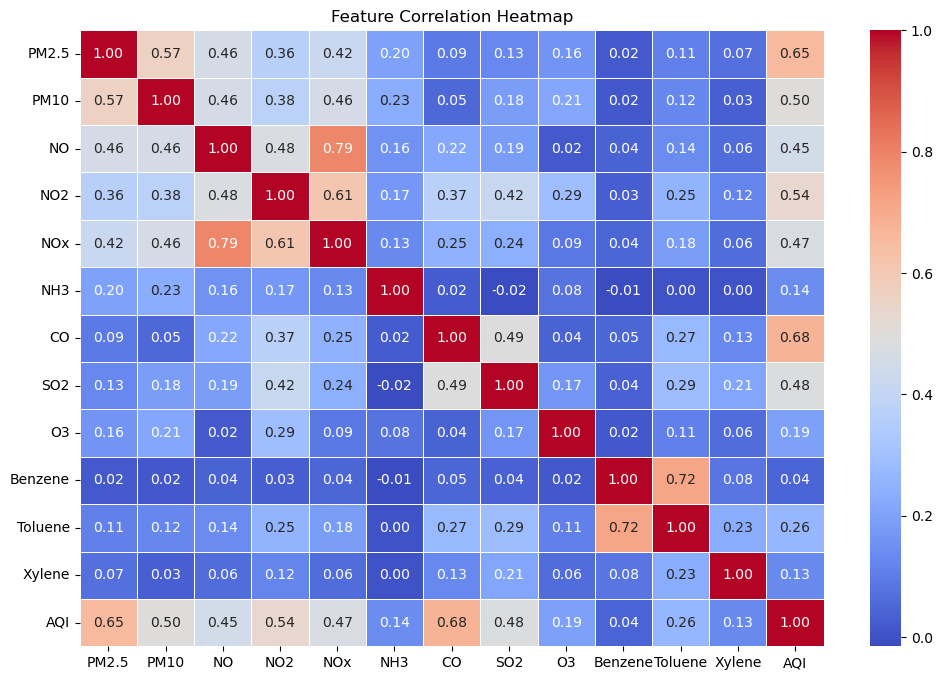

In [45]:
# Select only numerical columns for correlation
num_df = df.select_dtypes(include=['number'])  # Keep only numeric columns

# Compute correlation matrix
corr_matrix = num_df.corr()

# Plot heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

## Splitting Data into Training and Testing Sets
We divide the dataset into training and test sets to evaluate model performance.

In [48]:
# Train-Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Feature Scaling

In [51]:
# Feature Scaling
# Standardize the dataset to have zero mean and unit variance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Baseline Model Training
First, we train each model with default hyperparameters to establish baseline performance.

In [54]:
from sklearn.ensemble import GradientBoostingRegressor

# Initialize and define models to be tested
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42)
}

In [56]:
results = {}
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2 Score': r2}
    print(f"{name} Performance:\nMAE: {mae:.2f}, RMSE: {rmse:.2f}, R2 Score: {r2:.2f}\n")

# Convert results to DataFrame for better visualization
results_df = pd.DataFrame(results).T
print(results_df)

Linear Regression Performance:
MAE: 31.20, RMSE: 59.11, R2 Score: 0.81

Random Forest Performance:
MAE: 20.59, RMSE: 40.48, R2 Score: 0.91

Gradient Boosting Performance:
MAE: 23.71, RMSE: 43.81, R2 Score: 0.90

                         MAE       RMSE  R2 Score
Linear Regression  31.203327  59.108362  0.809197
Random Forest      20.591788  40.480720  0.910508
Gradient Boosting  23.714891  43.814207  0.895162


# Baseline Model Performance Comparison

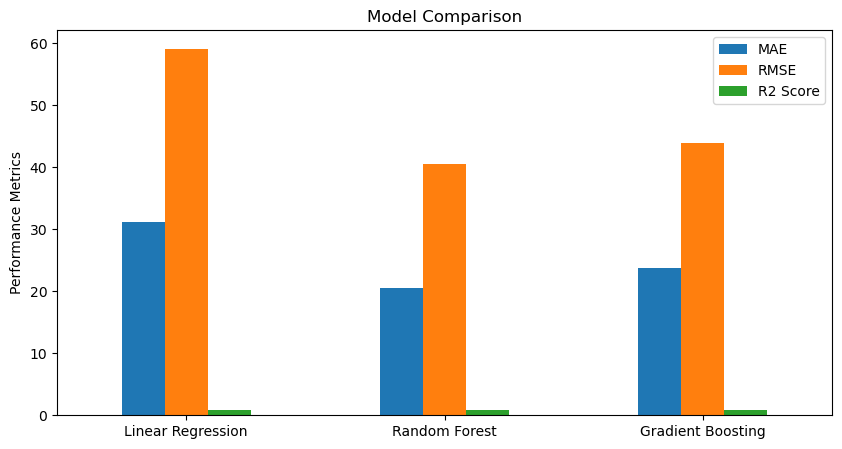

In [59]:
# Plot model performance
results_df.plot(kind='bar', figsize=(10, 5))
plt.title("Model Comparison")
plt.ylabel("Performance Metrics")
plt.xticks(rotation=0)
plt.show()

# Feature Importance Analysis

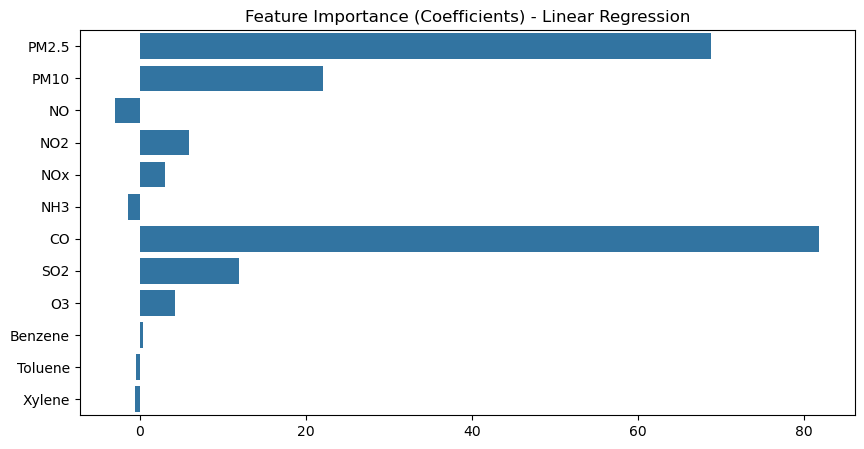

In [62]:
# Feature Importance Plot (For Linear Regression)
feature_importance = models["Linear Regression"].coef_
plt.figure(figsize=(10, 5))
sns.barplot(x=feature_importance, y=features)
plt.title("Feature Importance (Coefficients) - Linear Regression")
plt.show()

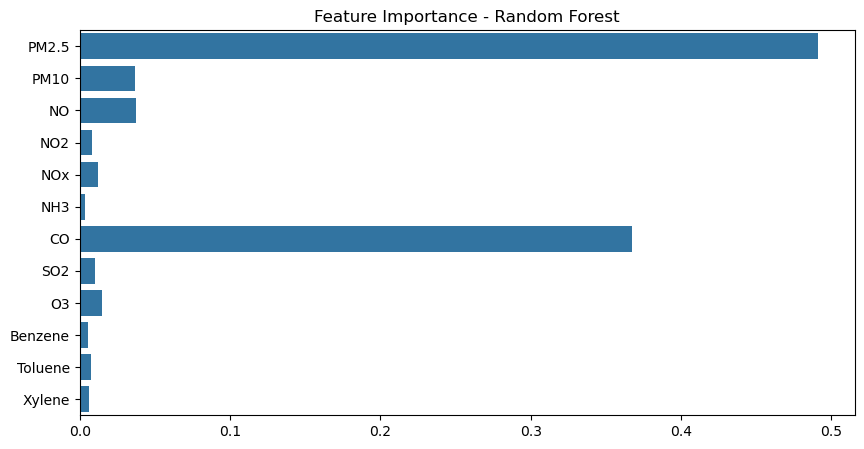

In [64]:
# Feature Importance Plot (For Random Forest)
feature_importance = models["Random Forest"].feature_importances_
plt.figure(figsize=(10, 5))
sns.barplot(x=feature_importance, y=features)
plt.title("Feature Importance - Random Forest")
plt.show()

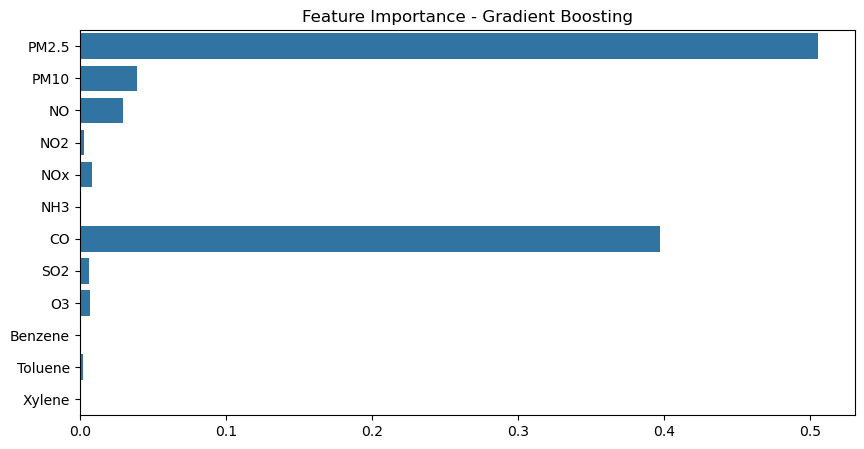

In [66]:
# Feature Importance Plot (For Gradient Boosting)
feature_importance = models["Gradient Boosting"].feature_importances_
plt.figure(figsize=(10, 5))
sns.barplot(x=feature_importance, y=features)
plt.title("Feature Importance - Gradient Boosting")
plt.show()

In [68]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Define AQI bucket boundaries
def aqi_to_bucket(aqi):
    if aqi <= 50:
        return 'Good'
    elif aqi <= 100:
        return 'Satisfactory'
    elif aqi <= 200:
        return 'Moderate'
    elif aqi <= 300:
        return 'Poor'
    elif aqi <= 400:
        return 'Very Poor'
    else:
        return 'Severe'

def evaluate_classification(y_test, y_pred, model_name):
    # Convert continuous predictions to categories
    y_test_buckets = y_test.apply(aqi_to_bucket)
    y_pred_buckets = pd.Series(y_pred).apply(aqi_to_bucket)

    # Per-class metrics
    labels = ['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']
    per_class_recall = recall_score(y_test_buckets, y_pred_buckets, labels=labels, average=None, zero_division=0)
    per_class_f1 = f1_score(y_test_buckets, y_pred_buckets, labels=labels, average=None, zero_division=0)
    per_class_precision = precision_score(y_test_buckets, y_pred_buckets, labels=labels, average=None, zero_division=0)

    # Overall (weighted) metrics
    accuracy = accuracy_score(y_test_buckets, y_pred_buckets)
    overall_precision = precision_score(y_test_buckets, y_pred_buckets, labels=labels, average='weighted', zero_division=0)
    overall_recall = recall_score(y_test_buckets, y_pred_buckets, labels=labels, average='weighted', zero_division=0)
    overall_f1 = f1_score(y_test_buckets, y_pred_buckets, labels=labels, average='weighted', zero_division=0)

    # Display
    print("=" * 50)
    print(f"    Performance Analysis - {model_name}")
    print("=" * 50)
    print(f"\n{'Category':<18} {'Recall':<10} {'F1':<10} {'Precision':<10}")
    print("-" * 48)
    for i, label in enumerate(labels):
        print(f"{label:<18} {per_class_recall[i]:<10.2f} {per_class_f1[i]:<10.2f} {per_class_precision[i]:<10.2f}")
    print("-" * 48)
    print(f"{'OVERALL':<18} {overall_recall:<10.2f} {overall_f1:<10.2f} {overall_precision:<10.2f}")
    print(f"\n        Overall Accuracy: {accuracy:.2f}")
    print("=" * 50)

    # Confusion Matrix
    cm = confusion_matrix(y_test_buckets, y_pred_buckets, labels=labels)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Hyperparameter Tuning and Full Evaluation
Each model is now tuned (where applicable) and evaluated on both regression metrics (MAE, RMSE, R²) and bucket-level classification metrics (accuracy, precision, recall, F1).

### Linear Regression
*Note: Linear Regression has no hyperparameters to tune, so no GridSearchCV is performed.*

Linear Regression Performance:
MAE: 31.20, RMSE: 59.11, R2 Score: 0.81
Predicted AQI values: [114.05122911 200.71997899 116.16856349 126.07120008  85.6955432
  74.53005568  71.12459293 100.35052258 139.55833073  57.31316645]


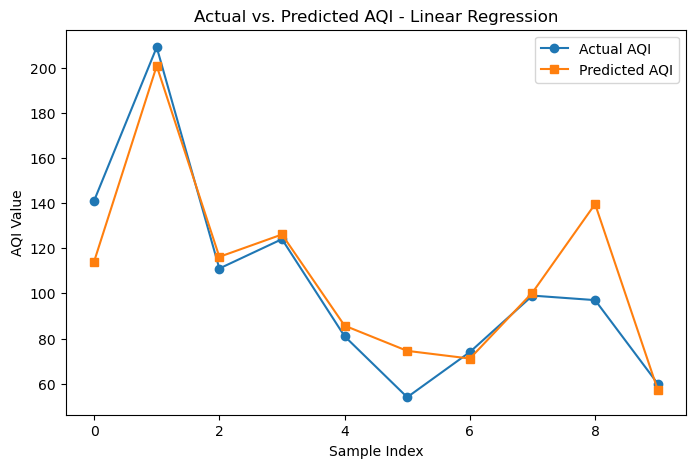

In [85]:
# --- Linear Regression ---
best_lr = LinearRegression()
best_lr.fit(X_train_scaled, y_train)
y_pred_lr = best_lr.predict(X_test_scaled)

# Regression metrics
mae = mean_absolute_error(y_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2 = r2_score(y_test, y_pred_lr)
print(f"Linear Regression Performance:\nMAE: {mae:.2f}, RMSE: {rmse:.2f}, R2 Score: {r2:.2f}")

# Sample predictions on first 5 test points
predictions_lr = best_lr.predict(X_test_scaled[:10])
print("Predicted AQI values:", predictions_lr)

# Plot Actual vs Predicted
plt.figure(figsize=(8, 5))
plt.plot(y_test[:10].values, label="Actual AQI", marker='o')
plt.plot(predictions_lr, label="Predicted AQI", marker='s')
plt.xlabel("Sample Index")
plt.ylabel("AQI Value")
plt.title("Actual vs. Predicted AQI - Linear Regression")
plt.legend()
plt.show()

    Performance Analysis - Linear Regression

Category           Recall     F1         Precision 
------------------------------------------------
Good               0.39       0.47       0.60      
Satisfactory       0.66       0.71       0.78      
Moderate           0.86       0.75       0.67      
Poor               0.60       0.55       0.51      
Very Poor          0.39       0.49       0.69      
Severe             0.76       0.77       0.77      
------------------------------------------------
OVERALL            0.69       0.68       0.69      

        Overall Accuracy: 0.69


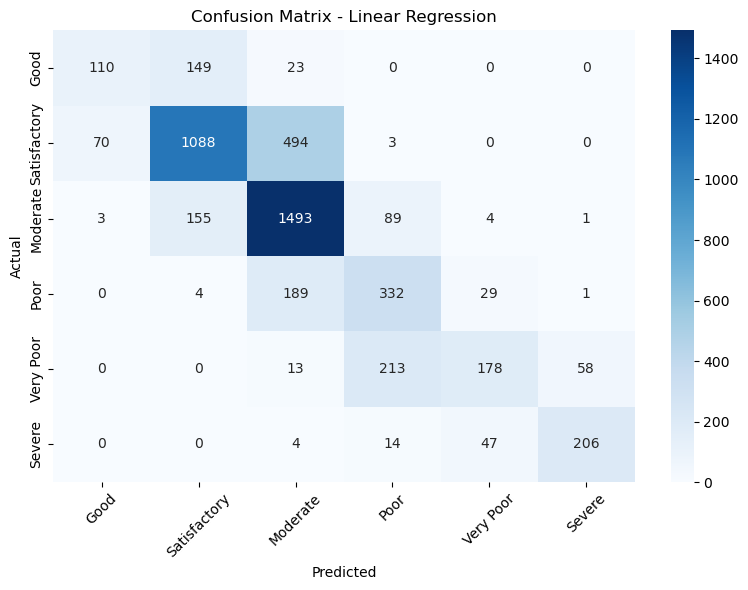

In [87]:
# --- Bucket-level classification metrics: Linear Regression ---
evaluate_classification(y_test, y_pred_lr, "Linear Regression")

### Random Forest

In [79]:
# Hyperparameter Tuning - Random Forest
rf_tuning_params = {
    'n_estimators': [100, 200],
    'max_depth': [None, 5, 10]
}

Best Random Forest Parameters: {'max_depth': None, 'n_estimators': 200}
Random Forest Performance:
MAE: 20.55, RMSE: 40.22, R2 Score: 0.91
Predicted AQI values: [ 95.54  206.13  101.07  150.55   76.6    63.62   63.93  102.805 134.92
  60.765]


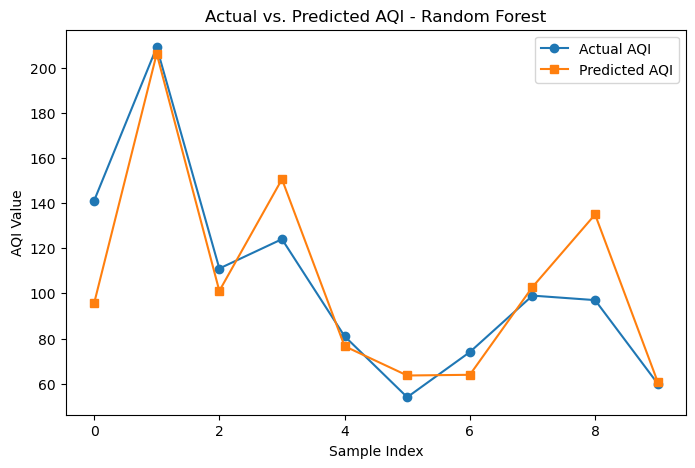

In [89]:
# --- Random Forest ---
grid_search_rf = GridSearchCV(RandomForestRegressor(random_state=42), rf_tuning_params, cv=3, scoring='r2', n_jobs=-1)
grid_search_rf.fit(X_train_scaled, y_train)
print(f"Best Random Forest Parameters: {grid_search_rf.best_params_}")

# Train the best model using the grid search's best params
best_rf = RandomForestRegressor(**grid_search_rf.best_params_, random_state=42)
best_rf.fit(X_train_scaled, y_train)
y_pred_rf = best_rf.predict(X_test_scaled)

# Regression metrics
mae = mean_absolute_error(y_test, y_pred_rf)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2 = r2_score(y_test, y_pred_rf)
print(f"Random Forest Performance:\nMAE: {mae:.2f}, RMSE: {rmse:.2f}, R2 Score: {r2:.2f}")

# Sample predictions on first 5 test points
predictions_rf = best_rf.predict(X_test_scaled[:10])
print("Predicted AQI values:", predictions_rf)

# Plot Actual vs Predicted
plt.figure(figsize=(8, 5))
plt.plot(y_test[:10].values, label="Actual AQI", marker='o')
plt.plot(predictions_rf, label="Predicted AQI", marker='s')
plt.xlabel("Sample Index")
plt.ylabel("AQI Value")
plt.title("Actual vs. Predicted AQI - Random Forest")
plt.legend()
plt.show()

    Performance Analysis - Random Forest

Category           Recall     F1         Precision 
------------------------------------------------
Good               0.57       0.68       0.86      
Satisfactory       0.82       0.83       0.85      
Moderate           0.87       0.83       0.79      
Poor               0.69       0.67       0.66      
Very Poor          0.70       0.74       0.78      
Severe             0.83       0.84       0.85      
------------------------------------------------
OVERALL            0.80       0.80       0.80      

        Overall Accuracy: 0.80


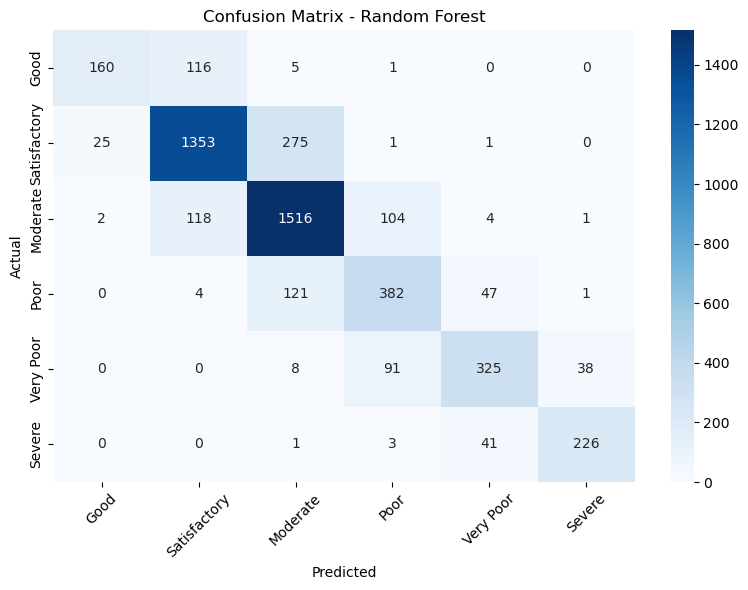

In [91]:
# --- Bucket-level classification metrics: Random Forest ---
evaluate_classification(y_test, y_pred_rf, "Random Forest")

### Gradient Boosting

In [94]:
# Hyperparameter Tuning - Gradient Boosting
gb_tuning_params = {
    'n_estimators': [50, 100],
    'learning_rate': [0.1, 0.2],
    'max_depth': [3, 5]
}

Best Gradient Boosting Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}
Gradient Boosting Performance:
MAE: 21.63, RMSE: 40.38, R2 Score: 0.91
Predicted AQI values: [ 96.32135881 216.73030591 100.20276883 116.52047696  80.24140976
  63.73121557  66.76994696 106.51560523 121.8078626   66.56840047]


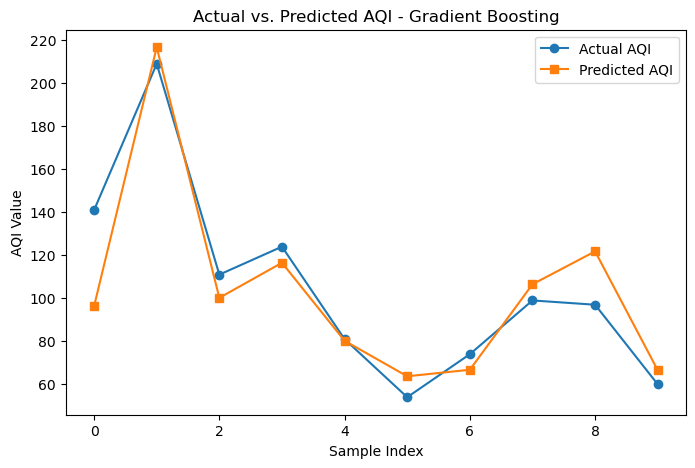

In [96]:
# --- Gradient Boosting ---
grid_search_gb = GridSearchCV(GradientBoostingRegressor(random_state=42), gb_tuning_params, cv=3, scoring='r2', n_jobs=-1)
grid_search_gb.fit(X_train_scaled, y_train)
print(f"Best Gradient Boosting Parameters: {grid_search_gb.best_params_}")

# Train the best model using the grid search's best params
best_gb = GradientBoostingRegressor(**grid_search_gb.best_params_, random_state=42)
best_gb.fit(X_train_scaled, y_train)
y_pred_gb = best_gb.predict(X_test_scaled)

# Regression metrics
mae = mean_absolute_error(y_test, y_pred_gb)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2 = r2_score(y_test, y_pred_gb)
print(f"Gradient Boosting Performance:\nMAE: {mae:.2f}, RMSE: {rmse:.2f}, R2 Score: {r2:.2f}")

# Sample predictions on first 5 test points
predictions_gb = best_gb.predict(X_test_scaled[:10])
print("Predicted AQI values:", predictions_gb)

# Plot Actual vs Predicted
plt.figure(figsize=(8, 5))
plt.plot(y_test[:10].values, label="Actual AQI", marker='o')
plt.plot(predictions_gb, label="Predicted AQI", marker='s')
plt.xlabel("Sample Index")
plt.ylabel("AQI Value")
plt.title("Actual vs. Predicted AQI - Gradient Boosting")
plt.legend()
plt.show()

    Performance Analysis - Gradient Boosting

Category           Recall     F1         Precision 
------------------------------------------------
Good               0.38       0.52       0.85      
Satisfactory       0.81       0.80       0.79      
Moderate           0.83       0.80       0.78      
Poor               0.71       0.68       0.66      
Very Poor          0.70       0.74       0.78      
Severe             0.81       0.83       0.84      
------------------------------------------------
OVERALL            0.77       0.77       0.78      

        Overall Accuracy: 0.77


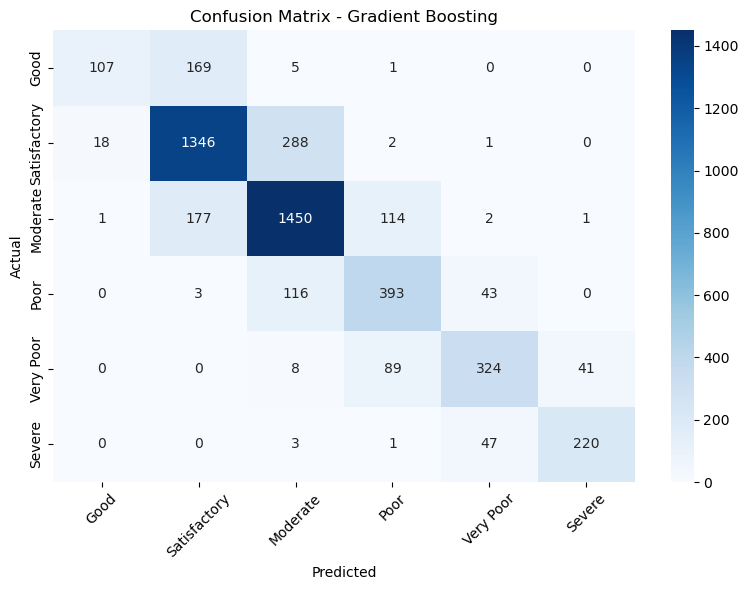

In [98]:
# --- Bucket-level classification metrics: Gradient Boosting ---
evaluate_classification(y_test, y_pred_gb, "Gradient Boosting")

### Neural Network (MLP)
A feedforward neural network (multi-layer perceptron) is the appropriate deep learning
baseline for this tabular dataset. The architecture consists of three hidden dense layers
with ReLU activations and dropout regularization, followed by a single linear output
neuron for regression. Training uses Adam optimizer with MSE loss and early stopping
on a 20% validation split to prevent overfitting.

In [101]:
# Set seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Build MLP architecture
model_nn = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)  # linear output for regression
])

model_nn.compile(optimizer='adam', loss='mse', metrics=['mae'])
model_nn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,457 (13.50 KB)

 Trainable params: 3,457 (13.50 KB)

 Non-trainable params: 0 (0.00 B)

Trained for 21 epochs (stopped early from max 50)


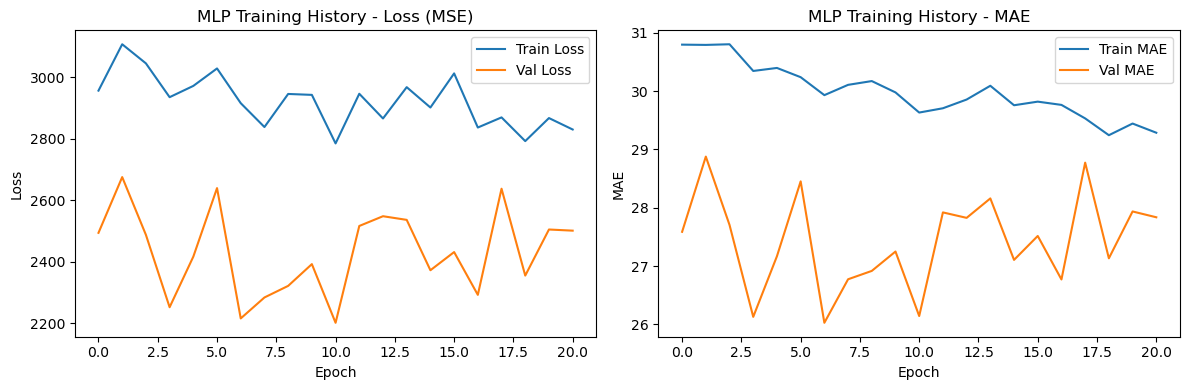

In [107]:
# Train with early stopping to prevent overfitting
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model_nn.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=0
)

print(f"Trained for {len(history.history['loss'])} epochs (stopped early from max 50)")

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('MLP Training History - Loss (MSE)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history.history['mae'], label='Train MAE')
axes[1].plot(history.history['val_mae'], label='Val MAE')
axes[1].set_title('MLP Training History - MAE')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()

plt.tight_layout()
plt.show()

Neural Network (MLP) Performance:
MAE: 26.08, RMSE: 50.32, R2 Score: 0.86
Predicted AQI values: [103.273544 199.26009   98.37945  119.57285   94.89892   79.71892
  69.29627  100.01215  130.0288    73.76344 ]


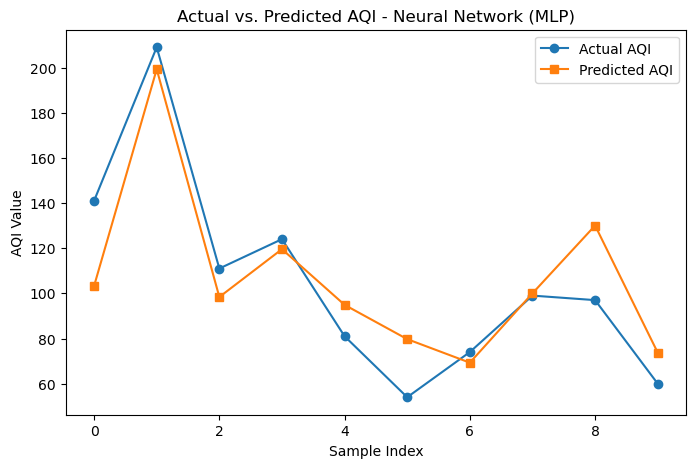

In [109]:
# --- Neural Network (MLP) ---
y_pred_nn = model_nn.predict(X_test_scaled, verbose=0).flatten()

# Regression metrics
mae = mean_absolute_error(y_test, y_pred_nn)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_nn))
r2 = r2_score(y_test, y_pred_nn)
print(f"Neural Network (MLP) Performance:\nMAE: {mae:.2f}, RMSE: {rmse:.2f}, R2 Score: {r2:.2f}")

# Sample predictions on first 5 test points
predictions_nn = model_nn.predict(X_test_scaled[:10], verbose=0).flatten()
print("Predicted AQI values:", predictions_nn)

# Plot Actual vs Predicted
plt.figure(figsize=(8, 5))
plt.plot(y_test[:10].values, label="Actual AQI", marker='o')
plt.plot(predictions_nn, label="Predicted AQI", marker='s')
plt.xlabel("Sample Index")
plt.ylabel("AQI Value")
plt.title("Actual vs. Predicted AQI - Neural Network (MLP)")
plt.legend()
plt.show()

    Performance Analysis - Neural Network (MLP)

Category           Recall     F1         Precision 
------------------------------------------------
Good               0.02       0.03       0.45      
Satisfactory       0.84       0.78       0.73      
Moderate           0.81       0.79       0.77      
Poor               0.70       0.61       0.54      
Very Poor          0.49       0.58       0.71      
Severe             0.68       0.78       0.91      
------------------------------------------------
OVERALL            0.73       0.70       0.72      

        Overall Accuracy: 0.73


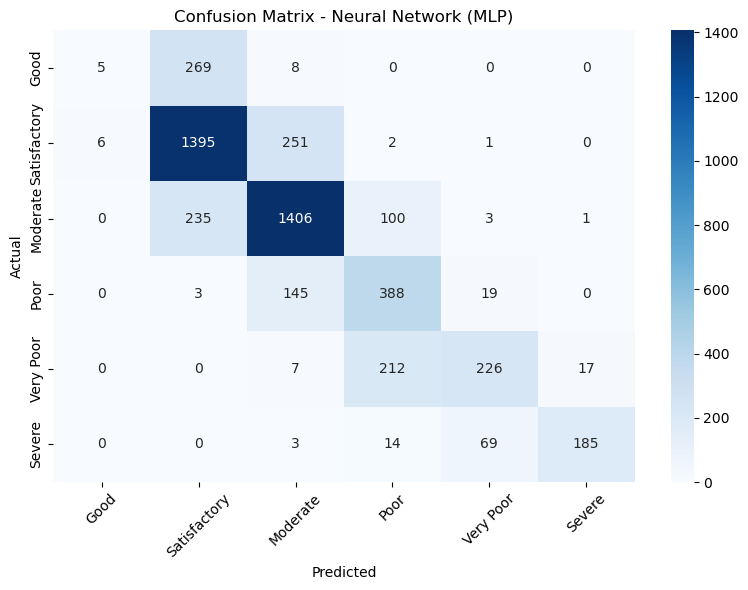

In [111]:
# --- Bucket-level classification metrics: Neural Network (MLP) ---
evaluate_classification(y_test, y_pred_nn, "Neural Network (MLP)")

# Consolidated Model Comparison
This is the primary results table for the paper. It combines regression metrics (on continuous AQI) and bucket-level classification metrics (derived via post-hoc bucketization) for all tuned models. The LSTM results will be added to this table once implemented.

In [114]:
# ============================================================
# Consolidated Model Comparison - Tuned Models
# ============================================================
labels = ['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']

final_results = {}
for name, y_pred in [("Linear Regression", y_pred_lr),
                     ("Random Forest", y_pred_rf),
                     ("Gradient Boosting", y_pred_gb),
                     ("Neural Network (MLP)", y_pred_nn)]:
    # Regression metrics (continuous AQI prediction)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    # Bucket-level classification metrics (post-hoc bucketization)
    y_test_buckets = y_test.apply(aqi_to_bucket)
    y_pred_buckets = pd.Series(y_pred).apply(aqi_to_bucket)
    acc = accuracy_score(y_test_buckets, y_pred_buckets)
    prec = precision_score(y_test_buckets, y_pred_buckets, labels=labels, average='weighted', zero_division=0)
    rec = recall_score(y_test_buckets, y_pred_buckets, labels=labels, average='weighted', zero_division=0)
    f1 = f1_score(y_test_buckets, y_pred_buckets, labels=labels, average='weighted', zero_division=0)

    final_results[name] = {
        'MAE': mae, 'RMSE': rmse, 'R²': r2,
        'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1
    }

final_df = pd.DataFrame(final_results).T
print("=" * 80)
print("  Final Model Comparison (Tuned)")
print("=" * 80)
print(final_df.round(3).to_string())
print("=" * 80)

  Final Model Comparison (Tuned)
                         MAE    RMSE     R²  Accuracy  Precision  Recall     F1
Linear Regression     31.203  59.108  0.809     0.686      0.693   0.686  0.678
Random Forest         20.549  40.216  0.912     0.797      0.800   0.797  0.796
Gradient Boosting     21.627  40.376  0.911     0.773      0.776   0.773  0.769
Neural Network (MLP)  26.084  50.319  0.862     0.725      0.718   0.725  0.705


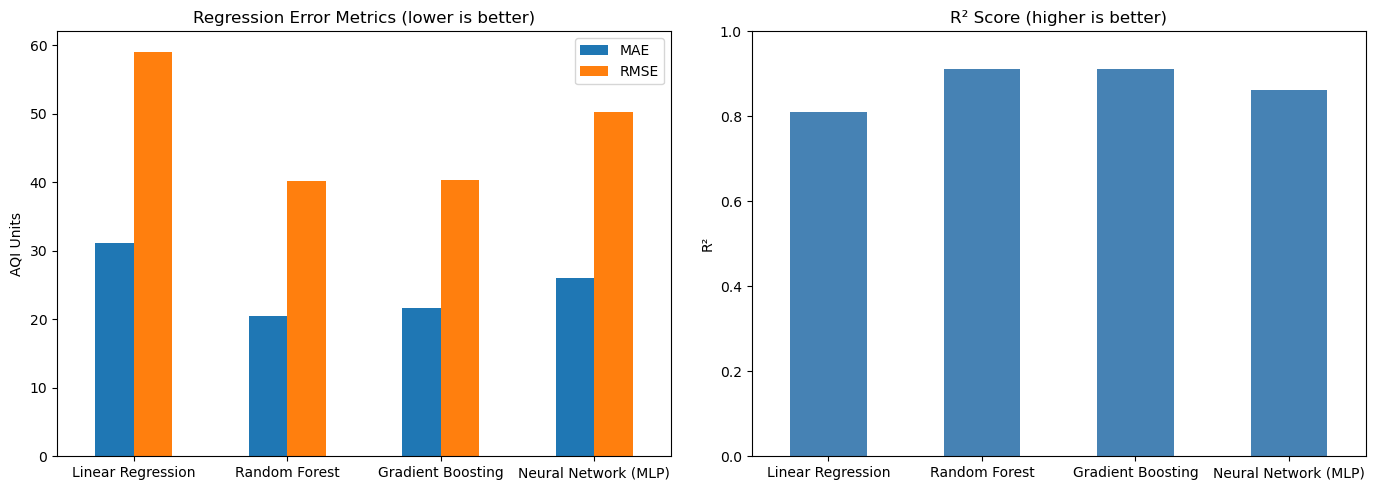

In [116]:
# Visualization: regression error metrics (MAE, RMSE on AQI scale; R² on 0-1 scale)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

final_df[['MAE', 'RMSE']].plot(kind='bar', ax=axes[0], rot=0)
axes[0].set_title("Regression Error Metrics (lower is better)")
axes[0].set_ylabel("AQI Units")
axes[0].legend(loc='upper right')

final_df[['R²']].plot(kind='bar', ax=axes[1], rot=0, color='steelblue', legend=False)
axes[1].set_title("R² Score (higher is better)")
axes[1].set_ylabel("R²")
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

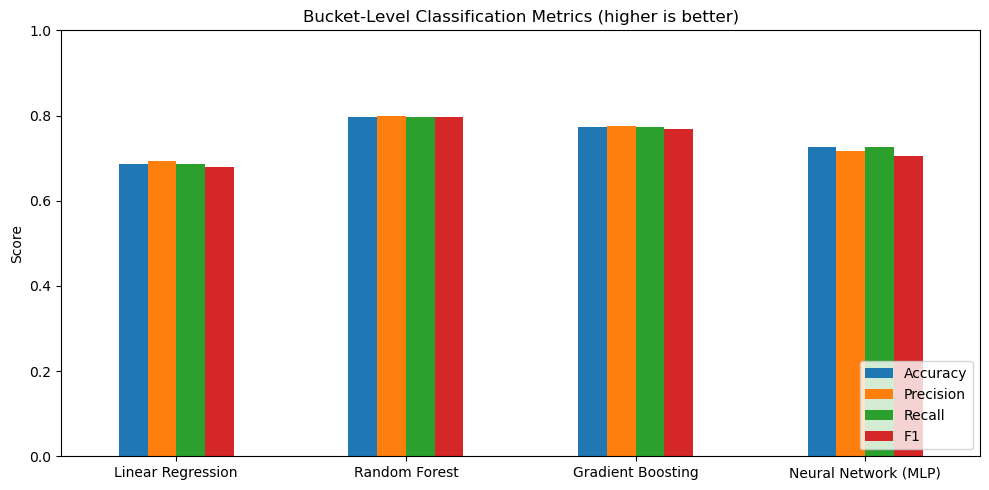

In [118]:
# Visualization: bucket-level classification metrics (all on 0-1 scale)
final_df[['Accuracy', 'Precision', 'Recall', 'F1']].plot(kind='bar', figsize=(10, 5), rot=0)
plt.title("Bucket-Level Classification Metrics (higher is better)")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()